# Vegetative Growth

In nature plant species vary in their ability to adjust their growth (and thus morphology, physiology) in response to a unique environment: phenotypic plasticity.

Luckily for us, the **vegetative growth** of the oil palm **is fairly in-plastic (in-variable)**:

Roughly speaking, the vegetative growth follows a constant pattern: fronds (and thus the trunk) grow at a regular rate --- root growth is less well-understood.

To illustrate this consider the following graph of observations of generative/vegetative growth versus total growth:

(source: Corley and Tinker, 2005)

<img src="images/plasticity.png" alt="Plasticity of growth">

Thus, given some simple measurements **we can reliably model vegetative growth!**

In this example we will consider the modelling of vegetative growth in PalmSim.

To do so let us first (as always) import some basic python libraries (technical detail) and PalmSim.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib
plt.style.use('grayscale')
plt.rc('font', size=18)
plt.rc('legend', fontsize=14)

%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../PalmSim')
sys.path.append('../PalmSim/components')

from PalmField import PalmField

# Weather

Here let us consider Sumatran weather data.

In [3]:
weather_df = pd.read_csv('input/north_sumatra.csv',index_col='Date')

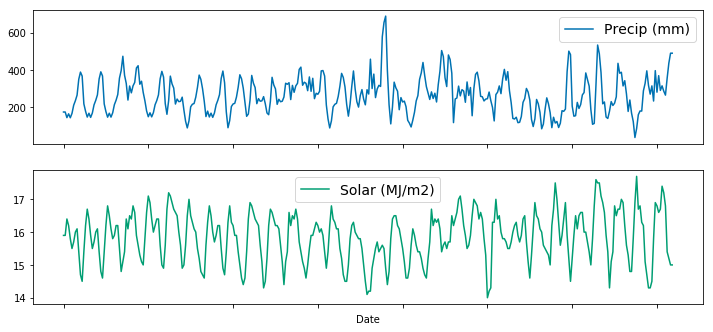

In [4]:
weather_df[['Precip (mm)','Solar (MJ/m2)']].plot(subplots=True,figsize=(12,6));

# PalmSim

Now let us run PalmSim and consider vegetative growth by highlighting the following model elements:

    - Weather
    - Fronds
    - Assimilate Pool
    - Trunk
    - Roots

In [5]:
# Initiatilize a field at DOP 1986 (coincides with the first weather data)
p = PalmField(year_of_planting=1986)

# Attach the weather data
p.weather.radiation_series = weather_df['Solar (MJ/m2)'].values
p.weather.rainfall_series = weather_df['Precip (mm)'].values

# Run the model for 360 months.
df = p.run(duration=360)

# Weather

Solar radiation drives plant growth. The main consideration here is that only a fraction of the sun-light is absorbed by the plant for this purpose --- the so-called photo-synthatically active radiation (PAR).

Here the fraction of PAR is taken into account to come to typically around 8 MJ/m2/day of photo-synthatically active radiation.

By running the following command we can inspect the status of the weather in the model:

In [6]:
p.weather

Object: weather
Version: 1.0.0.1

Property                       Value     Unit        
----------------------------------------------------
PAR_fraction                   0.5000    1           
radiation_PAR                  7.9500    MJ/m**2/day 
radiation_PAR_per_month        0.2385    GJ/m**2/month
radiation_visible              15.9000   MJ/m**2/day 
radiation_visible_per_month    0.4770    GJ/m**2/month
raindays                       15.0000   1/month     
rainfall                       173.6000  mm/month    

Note, given no data on the number of raindays we opt for a default number, here 15 days/month --- note, this is only of interest for water limited production.

# Fronds

The fronds emerge with a plastochron (time between emergent frond) of 8 (very young palm) to 16 days (mature palm):

Text(0.5,1,'Plastrochron (day)')

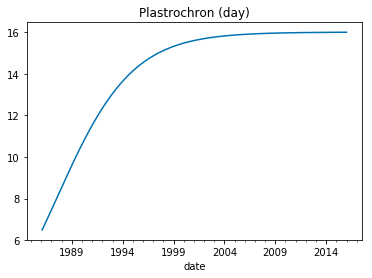

In [7]:
# note, to list all available output run "list(df)".
df['fronds plastochron (day)'].plot()
ax = plt.gca()
ax.set_title('Plastrochron (day)')

Each frond grows from a spear to an expanded leaf. We can model the resulting leaf area as a function of palm age (see e.g. Gerritsma, W. and Soebagyo, F.X., 1998):

Text(0.5,1,'Frond leaf area (m2)')

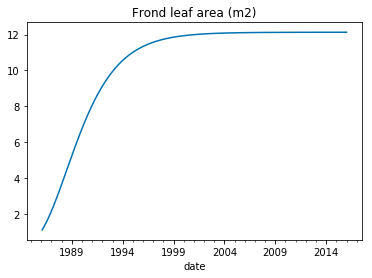

In [8]:
df['fronds mean leaf area (m**2)'].plot()
ax = plt.gca()
ax.set_title('Frond leaf area (m2)')

Accordingly the canopy closes as quantified by the fraction of intercepted light:

Text(0.5,1,'Fraction light intercepted (-)')

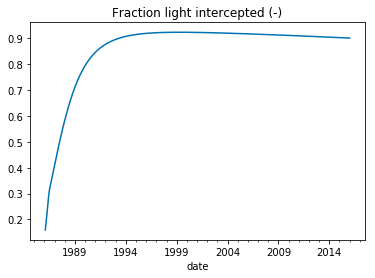

In [9]:
df['fronds fraction intercepted (1)'].plot()
ax = plt.gca()
ax.set_title('Fraction light intercepted (-)')

Let us inspect the fronds in the model:

Note, since we ran the model for 360 months here we consider the fronds at this time.

In [10]:
p.fronds

Object: fronds
Version: v0.01

Property                       Value     Unit        
----------------------------------------------------
assim_growth                   1.6099    tonne_CH2O/ha/month
assim_produced                 9.6057    tonne_CH2O/ha/month
count                          5778.6377 1/ha        
count_alt                      41.8742   1/palm      
fraction_intercepted           0.9010    1           
leaf_area                      7.0091    ha          
plastochron                    16.0069   day         
maintenance_requirement        2.6583    tonne_CH2O/ha/month
mass                           24.7864   tonne_DM/ha 
mean_leaf_area                 12.1294   m**2        
initiation_rate                1.8742    1/palm/month
specific_leaf_area             2.8278    cm**2/g_DM  
potential_growth_rate          1.2420    tonne_DM/ha/month
sink_strength_potential        1.8000    tonne_CH2O/ha/month
prune_rate_count               258.6377  1/ha/month  
prune_rate_mass    

Note that the fronds have a "potential growth rate" (determined by the breed) and thus an associated "potential sink strength".

These are related by the efficiency of (dry-matter) growth, the so-called "conversion efficiency" (g DM growth/g assimilate).


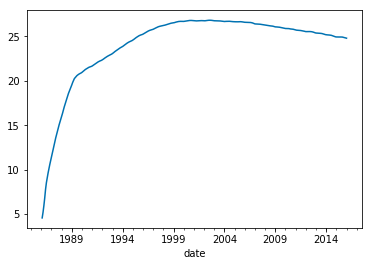

In [11]:
# the total frond mass over time
df['fronds mass (t/ha)'].plot()

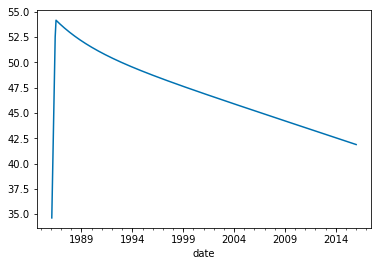

In [21]:
df['fronds count alt (1/palm)'].plot()

Most importantly the fronds produce assimilates, here "assim produced" --- around 9 ton/ha/month!

These produced assimilates drive the vegetative (and generative) growth.

# Assimilates

Assimilates produced by the fronds drive growth but also maintenance. Naturally this is considered for each of the following:
    
    - vegetative growth/maintenance
        - fronds
        - trunk
        - roots
    - generative growth/maintenance
    
You can check yourself that all the produced assimilates are directed towards growth and maintenance:

In [22]:
p.assimilates

Object: assimilates
Version: 1.0.0.1

Property                       Value     Unit        
----------------------------------------------------
assim_growth_fronds            1.6099    tonne_CH2O/ha/month
assim_growth_generative        3.0719    tonne_CH2O/ha/month
assim_growth_roots             0.2683    tonne_CH2O/ha/month
assim_growth_total             4.9948    tonne_CH2O/ha/month
assim_growth_trunk             0.0447    tonne_CH2O/ha/month
assim_growth_vegetative        1.9229    tonne_CH2O/ha/month
assim_maintenance_fronds       2.6599    tonne_CH2O/ha/month
assim_maintenance_generative   0.6549    tonne_CH2O/ha/month
assim_maintenance_vegetative   3.9576    tonne_CH2O/ha/month
assim_maintenance_roots        0.6340    tonne_CH2O/ha/month
assim_maintenance_total        4.6125    tonne_CH2O/ha/month
assim_maintenance_trunk        0.6636    tonne_CH2O/ha/month
assim_produced                 9.6073    tonne_CH2O/ha/month
assim_roots_fraction           0.1395    1           
assim_tr

These assimilate flows change over time in relation to the weather and age of the palm:

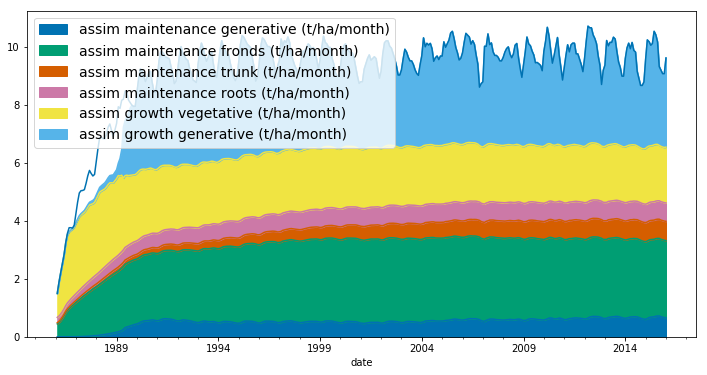

In [23]:
ax = df[['assim maintenance generative (t/ha/month)',
     'assim maintenance fronds (t/ha/month)',
     'assim maintenance trunk (t/ha/month)',
     'assim maintenance roots (t/ha/month)',
     'assim growth vegetative (t/ha/month)',
     'assim growth generative (t/ha/month)',
     ]].plot.area(figsize=(12,6))

df['assim produced (t/ha/month)'].plot(ax=ax)

Note, it is well-known that palms down-regulate their photo-synthesis untill the first bunches arrive. This shows as a feature in the model in terms of a gap between produced and used assimilates: the palm must down-regulate.

The amount of assimilates for vegetative growth directed to the fronds, trunk and roots is determined according to their (potential) sink strengths.

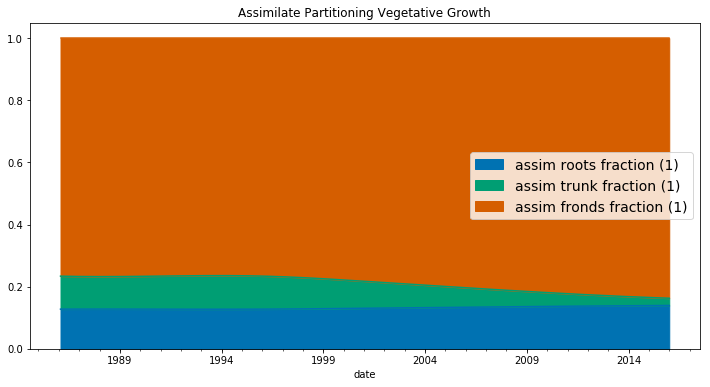

In [24]:
df[['assim roots fraction (1)','assim trunk fraction (1)','assim fronds fraction (1)']].plot.area(figsize=(12,6))
ax = plt.gca()
ax.set_title('Assimilate Partitioning Vegetative Growth');

As the phyllochron decreases so does the trunk growth, considering the fronds this decrease (in count growth) is compensated by the increasing leaf size. Root growth/turn-over is here considered to be relatively static.

# Trunk

Trunks grow to around 350 kg DM for a palm of 30 years old (see e.g. the 1971 paper by Corley). Given the assimilate partitioning this is what we find in the model.

In [25]:
p.trunk

Object: trunk
Version: v0.01

Property                       Value     Unit        
----------------------------------------------------
assim_growth                   0.0447    tonne_CH2O/ha/month
maintenance_requirement        0.6641    tonne_CH2O/ha/month
mass                           44.2735   tonne_DM/ha 
mass_alt                       320.8225  kg_DM/palm  
mass_change_rate               0.0309    tonne_DM/ha/month
mass_change_rate_alt           0.2236    kg_DM/palm/month
mass_growth_rate               0.0309    tonne_DM/ha/month
mass_loss_rate                 0.0000    tonne_DM/ha/month
potential_growth_rate          0.0345    tonne_DM/ha/month
sink_strength_potential        0.0500    tonne_CH2O/ha/month

Text(0.5,1,'Trunk mass (kg DM/palm)')

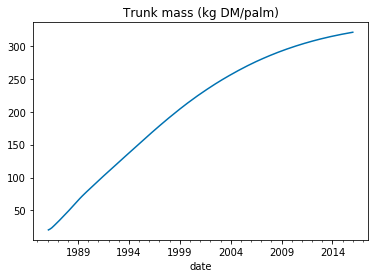

In [26]:
# trunk mass in kg DM
df['trunk mass alt (kg DM/palm)'].plot()
ax = plt.gca()
ax.set_title('Trunk mass (kg DM/palm)')

# Roots

Since roots live below the ground they are not easily studied, as such relatively little is known about palm roots.

Given the knowledge that is available and the according assimilate partitioning we come to the following:

In [27]:
p.roots

Object: roots
Version: 1.0.0.1

Property                       Value     Unit        
----------------------------------------------------
assim_growth                   0.2683    tonne_CH2O/ha/month
maintenance_requirement        0.6340    tonne_CH2O/ha/month
mass                           9.6063    tonne_DM/ha 
mass_change_rate               0.0003    tonne_DM/ha/month
mass_growth_rate               0.1851    tonne_DM/ha/month
mass_loss_rate                 0.1849    tonne_DM/ha/month
potential_growth_rate          0.2070    tonne_DM/ha/month
sink_strength_potential        0.3000    tonne_CH2O/ha/month

Text(0.5,1,'Roots mass (kg DM/palm)')

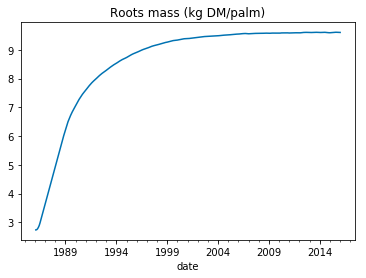

In [28]:
df['roots mass (t/ha)'].plot()
ax = plt.gca()
ax.set_title('Roots mass (kg DM/palm)')

# Conclusion

The vegetative growth of oil palm lends itself to modelling and can be modelled in a reliable manner.

Note, in the next update of PalmSim we will model the fronds as cohorts (in the same manner as the inflorescences) which go through phenological phases --- this will be interesting in itself but will however not entail any changes to e.g. yield.

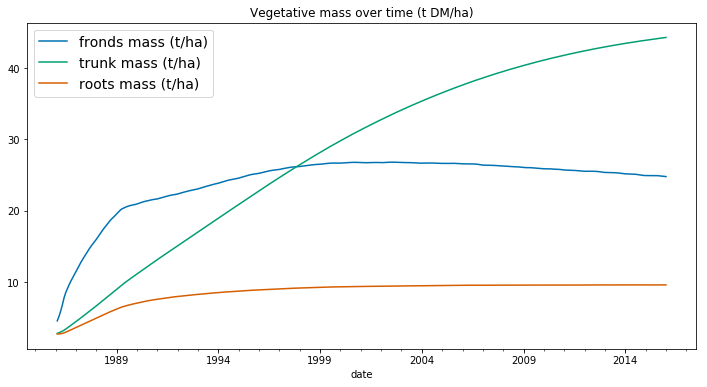

In [29]:
df[['fronds mass (t/ha)','trunk mass (t/ha)','roots mass (t/ha)']].plot(figsize=(12,6))
ax = plt.gca()
ax.set_title('Vegetative mass over time (t DM/ha)');

## Conclusion

This concludes this example.